# Multichannel Hidden Markov Models (MHMM) with Sequenzo - biofam Dataset

This tutorial demonstrates how to use **multichannel HMMs** for life course analysis with the Sequenzo package. While the companion mvad tutorial uses a single-channel HMM, this tutorial shows how to model multiple parallel life domains simultaneously.

## About the Dataset

The **biofam** dataset, originally from the Swiss Household Panel and distributed with the R seqHMM package, tracks **2000 individuals** across three dimensions of family life from age 15 to 30 (16 annual observations). Each dimension is a separate **channel** with binary states:

| Channel | States | Description |
|---------|--------|-------------|
| Marriage | 0 = not married, 1 = married | Whether the person is currently married |
| Parenthood | 0 = no children, 1 = has children | Whether the person has become a parent |
| Residence | 0 = with parents, 1 = left home | Whether the person has left the parental home |

This is a **three-channel** dataset: each individual has three parallel sequences running over the same time axis. A single-channel approach would lose the joint information about how these events relate to each other in time. For example, does leaving home typically happen before or after marriage? Do some people have children before leaving home?

## Research Question

**Can we identify life stages that jointly capture the timing and ordering of marriage, parenthood, and leaving home between ages 15 and 30?**

A multichannel HMM addresses this by finding hidden states that describe a *combination* of statuses across all three channels simultaneously. For instance, one hidden state might represent "single, childless, living with parents" (the typical starting position), while another represents "married with children, living independently" (a common endpoint).

## Why Multichannel?

In a single-channel analysis, we could combine the three binary variables into 2 x 2 x 2 = 8 composite states and fit a standard HMM. But a multichannel HMM has two advantages:

1. It models each channel's emission probabilities separately, making the parameters more interpretable.
2. It allows the channels to have different numbers of states (e.g., if marriage had 3 categories instead of 2).

In this tutorial, we will:
1. Load and prepare the three-channel biofam data
2. Explore the state distributions in each channel over time
3. Build and fit a multichannel HMM
4. Select the optimal number of hidden states
5. Decode hidden life stages and interpret the results

## Step 1: Import Libraries and Load Data

In [6]:
# Import libraries
from sequenzo import SequenceData
from sequenzo.seqhmm import (
    build_hmm, fit_model, predict, posterior_probs, plot_hmm,
    aic, bic
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
# Load the three channel CSVs
df_married = pd.read_csv("biofam_married_domain.csv")
df_child   = pd.read_csv("biofam_child_domain.csv")
df_left    = pd.read_csv("biofam_left_domain.csv")

print(f"Marriage channel:   {df_married.shape}")
print(f"Parenthood channel: {df_child.shape}")
print(f"Residence channel:  {df_left.shape}")
print(f"\nFirst individual (marriage): {df_married.iloc[0, 1:].tolist()}")

Marriage channel:   (2000, 17)
Parenthood channel: (2000, 17)
Residence channel:  (2000, 17)

First individual (marriage): [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1]


## Step 2: Prepare Sequence Data

For a multichannel HMM, we create one `SequenceData` object per channel. All channels must share the same time axis and the same number of individuals.

The raw data uses integer codes (0 and 1). We map these to meaningful string labels so the output is easier to interpret.

In [9]:
# Time columns: ages 15 to 30
TIME_COLS = [str(a) for a in range(15, 31)]
print(f"Time points: {len(TIME_COLS)} (age {TIME_COLS[0]} to {TIME_COLS[-1]})")

# Map integer codes to meaningful labels
MARRIED_STATES = ["not married", "married"]
CHILD_STATES   = ["no children", "has children"]
LEFT_STATES    = ["with parents", "left home"]

# Convert integer columns to string labels
married_label_map = {0: "not married", 1: "married"}
child_label_map   = {0: "no children", 1: "has children"}
left_label_map    = {0: "with parents", 1: "left home"}

for col in TIME_COLS:
    df_married[col] = df_married[col].map(married_label_map)
    df_child[col]   = df_child[col].map(child_label_map)
    df_left[col]    = df_left[col].map(left_label_map)

print(f"First individual (marriage, after mapping): {df_married.iloc[0][TIME_COLS].tolist()}")

Time points: 16 (age 15 to 30)
First individual (marriage, after mapping): ['not married', 'not married', 'not married', 'not married', 'not married', 'not married', 'not married', 'not married', 'not married', 'married', 'married', 'married', 'married', 'married', 'married', 'married']


In [10]:
# Create one SequenceData object per channel
seq_married = SequenceData(df_married, time=TIME_COLS, states=MARRIED_STATES, id_col="id")
seq_child   = SequenceData(df_child,   time=TIME_COLS, states=CHILD_STATES,   id_col="id")
seq_left    = SequenceData(df_left,    time=TIME_COLS, states=LEFT_STATES,    id_col="id")

print(f"Marriage:   {seq_married.n_sequences} sequences, alphabet = {seq_married.alphabet}")
print(f"Parenthood: {seq_child.n_sequences} sequences, alphabet = {seq_child.alphabet}")
print(f"Residence:  {seq_left.n_sequences} sequences, alphabet = {seq_left.alphabet}")


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 2000
[>] Number of time points: 16
[>] Min/Max sequence length: 16 / 16
[>] States: ['not married', 'married']
[>] Labels: ['not married', 'married']
[>] Weights: Not provided

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 2000
[>] Number of time points: 16
[>] Min/Max sequence length: 16 / 16
[>] States: ['no children', 'has children']
[>] Labels: ['no children', 'has children']
[>] Weights: Not provided

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 2000
[>] Number of time points: 16
[>] Min/Max sequence length: 16 / 16
[>] States: ['with parents', 'left home']
[>] Labels: ['with parents', 'left home']
[>] Weights: Not provided
Marriage:   2000 sequences, alphabet = ['not married', 'married']
Parenthood: 2000 sequences, alphabet = ['no children', 'has children']
Residence:  2000 sequences, alphabet = ['with parents', 'l

## Exploratory Visualization

Before building any model, we look at how each channel's state distribution evolves over time. This tells us *when* each life event typically occurs and helps us decide how many hidden states to use.

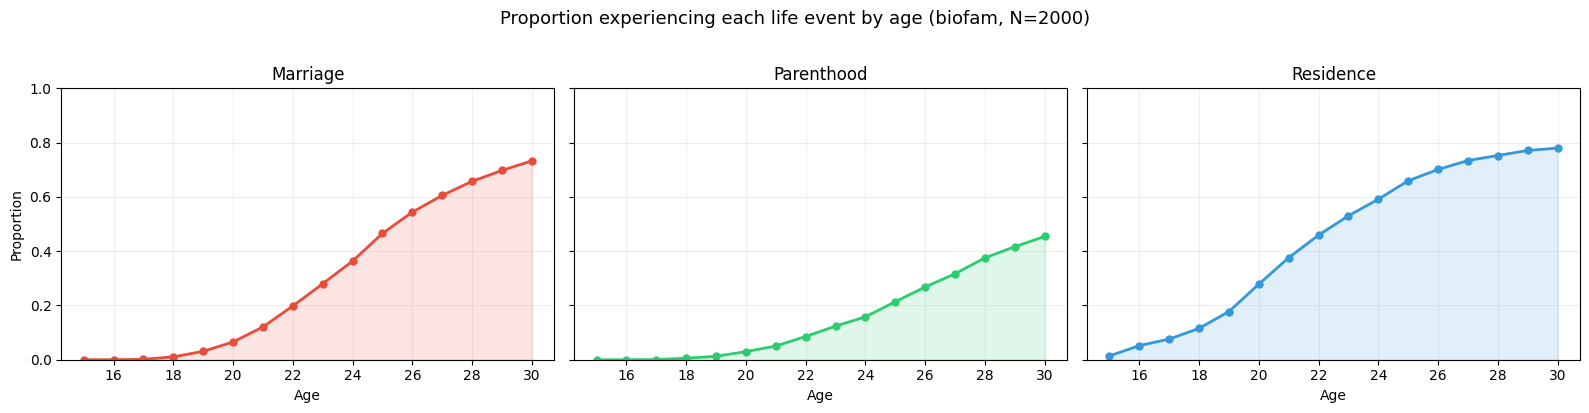

In [11]:
# Plot the proportion in the "active" state (married / has children / left home)
# for each channel over time

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

channels = [
    (df_married, "married",      "Marriage",    "#E74C3C"),
    (df_child,   "has children", "Parenthood",  "#2ECC71"),
    (df_left,    "left home",    "Residence",   "#3498DB"),
]

for ax, (df_ch, active_state, title, color) in zip(axes, channels):
    props = [(df_ch[t] == active_state).mean() for t in TIME_COLS]
    ax.plot(range(15, 31), props, 'o-', color=color, linewidth=2, markersize=5)
    ax.fill_between(range(15, 31), props, alpha=0.15, color=color)
    ax.set_xlabel("Age")
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Proportion")
fig.suptitle("Proportion experiencing each life event by age (biofam, N=2000)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

The three channels follow a clear temporal ordering:

- **Leaving home** starts earliest: a gradual rise from age 17, reaching about 78% by age 30.
- **Marriage** follows: very few are married before 20, then a steep rise to about 73% by age 30.
- **Parenthood** comes last: essentially zero before 20, reaching about 46% by age 30.

This suggests a typical sequence of life stages: (1) living with parents, single, childless; (2) left home but still single; (3) married, no children; (4) married with children. We will try 4-5 hidden states to capture this progression.

## Step 3: Build a Multichannel HMM

To build a multichannel HMM, we pass a **list of SequenceData objects** to `build_hmm()`. Each element in the list corresponds to one channel. The model will learn a single set of hidden states with separate emission probabilities for each channel.

We start with 4 hidden states based on our exploratory analysis.

In [12]:
# Build a multichannel HMM by passing a list of SequenceData objects
hmm = build_hmm(
    observations=[seq_married, seq_child, seq_left],  # list = multichannel
    n_states=4,
    channel_names=["Marriage", "Parenthood", "Residence"],
    state_names=[f"Stage {i+1}" for i in range(4)],
    random_state=42,
)

print(f"Number of hidden states: {hmm.n_states}")
print(f"Number of channels:     {hmm.n_channels}")
print(f"Channel names:          {hmm.channel_names}")
print(f"Symbols per channel:    {hmm.n_symbols}")  # list: [2, 2, 2]

Number of hidden states: 4
Number of channels:     3
Channel names:          ['Marriage', 'Parenthood', 'Residence']
Symbols per channel:    [2, 2, 2]


## Step 4: Fit the Model

The multichannel EM algorithm jointly estimates the transition matrix and one emission matrix per channel.

**Note on performance:** The current multichannel EM implementation is in pure Python (no C backend), so fitting 2000 sequences can be slow. We use a moderate number of iterations here. For production use, consider using a subset of sequences for initial exploration.

In [13]:
# Fit the multichannel HMM
# hmm.fit() automatically dispatches to the multichannel EM algorithm
# when observations is a list of SequenceData
hmm.fit(n_iter=50, tol=1e-3, verbose=True)

print(f"\nFitting completed!")
print(f"Log-likelihood: {hmm.log_likelihood:.2f}")
print(f"Converged:      {hmm.converged}")
print(f"Iterations:     {hmm.n_iter}")

Iteration 10: log-likelihood = -30234.2500
Iteration 20: log-likelihood = -15922.6133
Converged at iteration 30

Fitting completed!
Log-likelihood: -15757.91
Converged:      True
Iterations:     30


## Step 5: Examine the Fitted Model Parameters

In a multichannel HMM, we have:
- **One initial probability vector** (shared across channels)
- **One transition matrix** (shared across channels)
- **One emission matrix per channel** (each hidden state emits independently in each channel)

In [14]:
# Initial state probabilities
print("Initial State Probabilities:")
print("=" * 50)
for i in range(hmm.n_states):
    print(f"  {hmm.state_names[i]}: {hmm.initial_probs[i]:.4f} ({hmm.initial_probs[i]*100:.1f}%)")

# Transition matrix
print("\nTransition Probabilities:")
print("=" * 50)
trans_df = pd.DataFrame(
    hmm.transition_probs,
    index=hmm.state_names,
    columns=hmm.state_names,
)
print(trans_df.round(3))

Initial State Probabilities:
  Stage 1: 0.0140 (1.4%)
  Stage 2: 0.9860 (98.6%)
  Stage 3: 0.0000 (0.0%)
  Stage 4: 0.0000 (0.0%)

Transition Probabilities:
         Stage 1  Stage 2  Stage 3  Stage 4
Stage 1    0.890    0.000    0.083    0.027
Stage 2    0.054    0.888    0.047    0.012
Stage 3    0.000    0.012    0.846    0.142
Stage 4    0.000    0.006    0.000    0.994


In [15]:
# Emission probabilities: one matrix per channel
# This is what makes multichannel HMMs different from single-channel:
# each hidden state has a separate emission profile for each life domain

channel_info = [
    ("Marriage",    MARRIED_STATES),
    ("Parenthood", CHILD_STATES),
    ("Residence",  LEFT_STATES),
]

print("Emission Probabilities by Channel:")
print("=" * 60)
for ch_idx, (ch_name, ch_states) in enumerate(channel_info):
    print(f"\n--- {ch_name} ---")
    em_df = pd.DataFrame(
        hmm.emission_probs[ch_idx],
        index=hmm.state_names,
        columns=ch_states,
    )
    print(em_df.round(3))

Emission Probabilities by Channel:

--- Marriage ---
         not married  married
Stage 1        1.000    0.000
Stage 2        1.000    0.000
Stage 3        0.000    1.000
Stage 4        0.033    0.967

--- Parenthood ---
         no children  has children
Stage 1        1.000         0.000
Stage 2        0.999         0.001
Stage 3        1.000         0.000
Stage 4        0.000         1.000

--- Residence ---
         with parents  left home
Stage 1         0.000      1.000
Stage 2         1.000      0.000
Stage 3         0.311      0.689
Stage 4         0.000      1.000


In [16]:
# Combine all channels into a single summary table:
# For each hidden state, show the probability of the "active" status in each channel

print("Hidden State Profiles (probability of each life event):")
print("=" * 65)
print(f"{'State':<12} {'Married':>10} {'Has children':>15} {'Left home':>12}")
print("-" * 65)
for i in range(hmm.n_states):
    p_married  = hmm.emission_probs[0][i, MARRIED_STATES.index("married")]
    p_children = hmm.emission_probs[1][i, CHILD_STATES.index("has children")]
    p_left     = hmm.emission_probs[2][i, LEFT_STATES.index("left home")]
    print(f"{hmm.state_names[i]:<12} {p_married:10.3f} {p_children:15.3f} {p_left:12.3f}")

Hidden State Profiles (probability of each life event):
State           Married    Has children    Left home
-----------------------------------------------------------------
Stage 1           0.000           0.000        1.000
Stage 2           0.000           0.001        0.000
Stage 3           1.000           0.000        0.689
Stage 4           0.967           1.000        1.000


### Answering the Research Question: What are the hidden life stages?

By reading the profile table above, we can assign a substantive label to each hidden state based on its combination of emission probabilities across the three channels:

- A state with **low married, low children, low left home** represents the **"adolescent at home"** stage.
- A state with **low married, low children, high left home** represents **"independent but single"** — left home but not yet formed a family.
- A state with **high married, low children, high left home** represents **"married couple, no children"**.
- A state with **high married, high children, high left home** represents **"family with children"** — the most advanced family stage.

The transition matrix shows the typical ordering: most people progress from the adolescent stage through independence and marriage toward parenthood. The high diagonal values indicate that each stage is persistent — people tend to stay in a stage for several years before transitioning.

This is exactly the kind of insight that a multichannel HMM provides: a joint summary of how marriage, parenthood, and residential independence unfold together. A single-channel analysis on any one domain alone would miss the interplay between them.

## Step 6: Predict Hidden States (Viterbi Decoding)

We can decode the most likely hidden state path for each individual. In the multichannel setting, the Viterbi path summarises all three channels into a single sequence of life stages.

In [17]:
# Note: For multichannel HMMs, predict() is not available via hmmlearn
# because hmmlearn does not support multichannel models directly.
# We demonstrate decoding by examining posterior state assignments.

# Show fitted transition structure instead
print("Transition structure (non-trivial transitions > 0.01):")
print("=" * 50)
for i in range(hmm.n_states):
    for j in range(hmm.n_states):
        p = hmm.transition_probs[i, j]
        if p > 0.01:
            direction = "stays in" if i == j else "moves to"
            print(f"  {hmm.state_names[i]} {direction} {hmm.state_names[j]}: {p:.3f}")

Transition structure (non-trivial transitions > 0.01):
  Stage 1 stays in Stage 1: 0.890
  Stage 1 moves to Stage 3: 0.083
  Stage 1 moves to Stage 4: 0.027
  Stage 2 moves to Stage 1: 0.054
  Stage 2 stays in Stage 2: 0.888
  Stage 2 moves to Stage 3: 0.047
  Stage 2 moves to Stage 4: 0.012
  Stage 3 moves to Stage 2: 0.012
  Stage 3 stays in Stage 3: 0.846
  Stage 3 moves to Stage 4: 0.142
  Stage 4 stays in Stage 4: 0.994


## Step 7: Visualize the Model

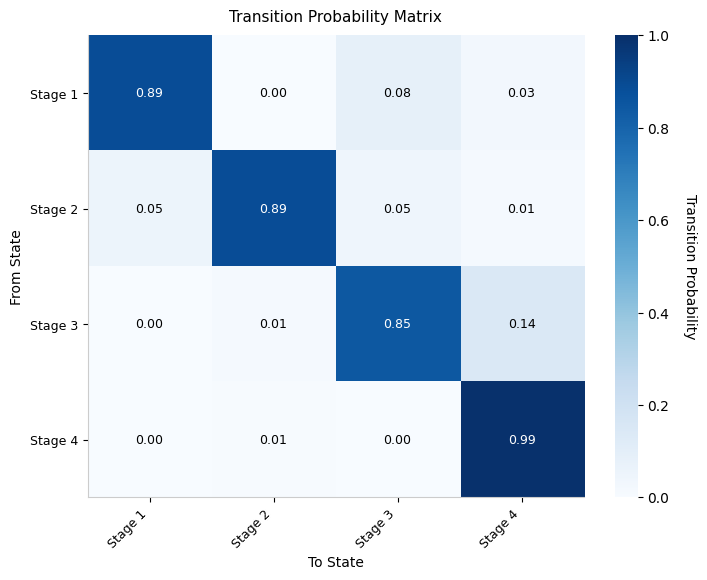

In [27]:
# Transition matrix (built-in)
plot_hmm(hmm, which='transition')
plt.show()

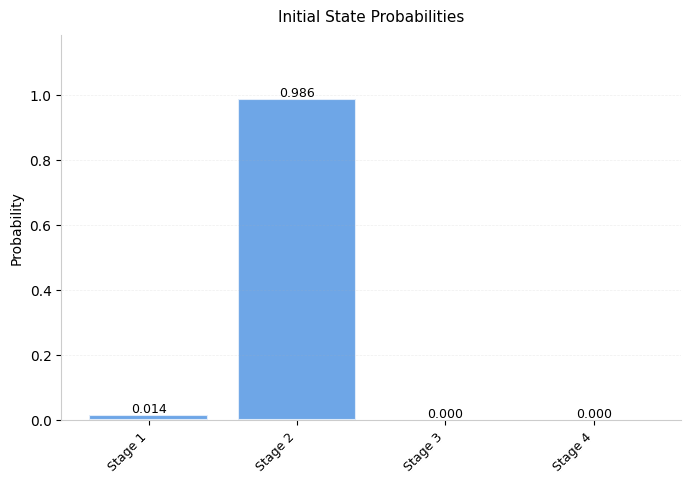

In [28]:
# Initial probabilities (built-in)
plot_hmm(hmm, which='initial')
plt.show()

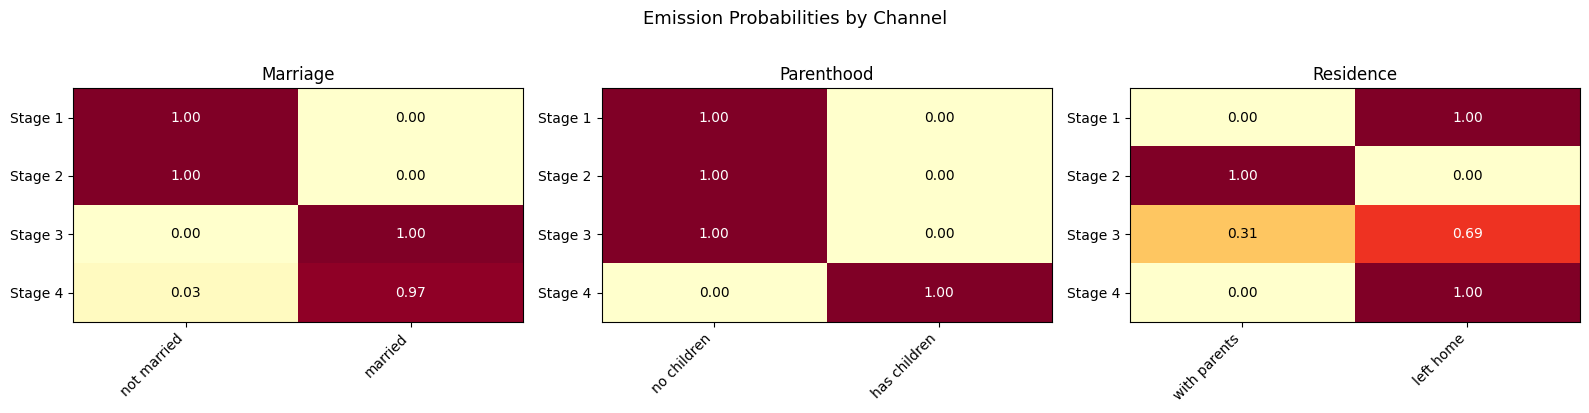

In [31]:
# Emission probabilities (manual, because plot_hmm doesn't support multichannel emission)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

channel_info = [
    ("Marriage",    MARRIED_STATES),
    ("Parenthood",  CHILD_STATES),
    ("Residence",   LEFT_STATES),
]

for ch_idx, (ch_name, ch_states) in enumerate(channel_info):
    ax = axes[ch_idx]
    emiss = hmm.emission_probs[ch_idx]
    im = ax.imshow(emiss, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(len(ch_states)))
    ax.set_xticklabels(ch_states, rotation=45, ha='right')
    ax.set_yticks(range(hmm.n_states))
    ax.set_yticklabels(hmm.state_names)
    ax.set_title(ch_name)
    for i in range(hmm.n_states):
        for j in range(len(ch_states)):
            color = 'white' if emiss[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{emiss[i,j]:.2f}', ha='center', va='center', color=color)

fig.suptitle("Emission Probabilities by Channel", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 8: Model Comparison

How many hidden states best describe the data? We fit models with 3 to 5 states and compare them using BIC.

**Note:** Because multichannel EM is slow in pure Python, we use a subset of 300 individuals for model comparison. This gives a rough guide; the final model can be fitted on the full data.

In [20]:
# Use a subset for faster model comparison
N_SUB = 300
sub_married = SequenceData(df_married.head(N_SUB), time=TIME_COLS,
                           states=MARRIED_STATES, id_col="id")
sub_child   = SequenceData(df_child.head(N_SUB), time=TIME_COLS,
                           states=CHILD_STATES, id_col="id")
sub_left    = SequenceData(df_left.head(N_SUB), time=TIME_COLS,
                           states=LEFT_STATES, id_col="id")

print(f"Using {N_SUB} sequences for model comparison")

results = []
for n in [3, 4, 5]:
    print(f"\nFitting {n}-state model...")
    h = build_hmm(
        observations=[sub_married, sub_child, sub_left],
        n_states=n,
        channel_names=["Marriage", "Parenthood", "Residence"],
        random_state=42,
    )
    h.fit(n_iter=30, tol=1e-3, verbose=False)
    results.append({
        "n_states": n,
        "logLik": h.log_likelihood,
    })
    print(f"  logLik = {h.log_likelihood:.1f}")

results_df = pd.DataFrame(results)
print("\nModel comparison (higher logLik is better):")
print(results_df.to_string(index=False))


[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 300
[>] Number of time points: 16
[>] Min/Max sequence length: 16 / 16
[>] States: ['not married', 'married']
[>] Labels: ['not married', 'married']
[>] Weights: Not provided

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 300
[>] Number of time points: 16
[>] Min/Max sequence length: 16 / 16
[>] States: ['no children', 'has children']
[>] Labels: ['no children', 'has children']
[>] Weights: Not provided

[>] SequenceData initialized successfully! Here's a summary:
[>] Number of sequences: 300
[>] Number of time points: 16
[>] Min/Max sequence length: 16 / 16
[>] States: ['with parents', 'left home']
[>] Labels: ['with parents', 'left home']
[>] Weights: Not provided
Using 300 sequences for model comparison

Fitting 3-state model...
  logLik = -4478.3

Fitting 4-state model...
  logLik = -2362.7

Fitting 5-state model...
  logLik = -2340.5

Model comparison (hig

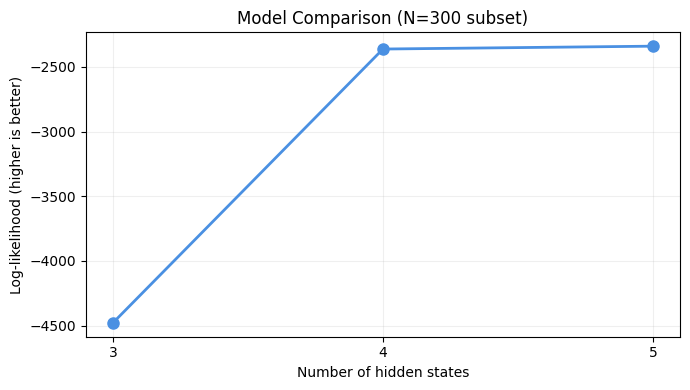

In [23]:
# Visualize model comparison
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results_df["n_states"], results_df["logLik"], 'o-',
        linewidth=2, markersize=8, color='#4A90E2')
ax.set_xlabel("Number of hidden states")
ax.set_ylabel("Log-likelihood (higher is better)")
ax.set_title(f"Model Comparison (N={N_SUB} subset)")
ax.set_xticks([3, 4, 5])
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Summary

In this tutorial, we applied a **multichannel HMM** to the biofam life course dataset (2000 individuals, 3 channels, ages 15-30).

### What we found

The multichannel HMM identified distinct life stages defined by combinations of marital status, parenthood, and residential independence. The typical progression runs from "adolescent at home" through "independent single" and "married couple" to "family with children", reflecting the well-known ordering of family formation events in European life courses.

### What makes multichannel different

The key advantage of the multichannel approach is that each hidden state is characterised by a *profile* across all three life domains simultaneously. Rather than analysing marriage, parenthood, and residence separately, the model captures how these dimensions co-evolve. This makes it possible to identify stages like "left home but not yet married" that would be invisible in any single-channel analysis.

### Workflow recap

| Step | What we did | Key function |
|------|-------------|-------------|
| Data preparation | Loaded 3 channel CSVs, mapped 0/1 to labels | `SequenceData()` x 3 |
| Exploratory visualization | Per-channel proportion curves over age | matplotlib |
| Multichannel HMM | Passed `[seq_married, seq_child, seq_left]` to `build_hmm()` | `build_hmm()` |
| Model fitting | Multichannel EM (dispatched automatically) | `hmm.fit()` |
| Parameter inspection | Per-channel emission matrices + combined profile table | pandas |
| Model comparison | Compared 3-5 states on a subset | `build_hmm()` + `hmm.fit()` |
| Visualization | Transition + initial via `plot_hmm()`; multichannel emission heatmaps via matplotlib | `plot_hmm()` + matplotlib |

### Next steps

- See the **pairfam** tutorial for Non-homogeneous HMM (NHMM) where transition probabilities depend on covariates